In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = pd.read_csv("Iris.csv")
df.shape
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

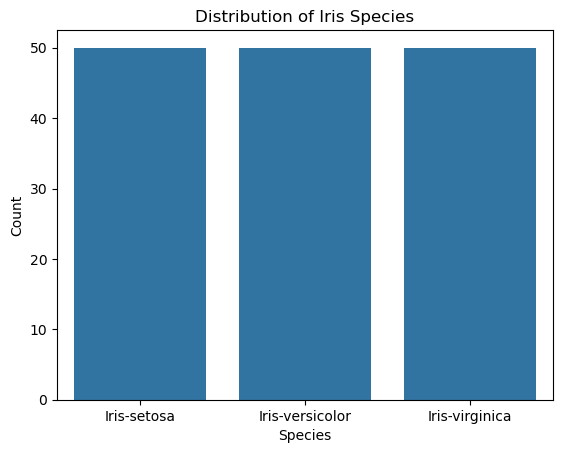

In [7]:
sns.countplot(x="Species", data=df)
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()


In [8]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

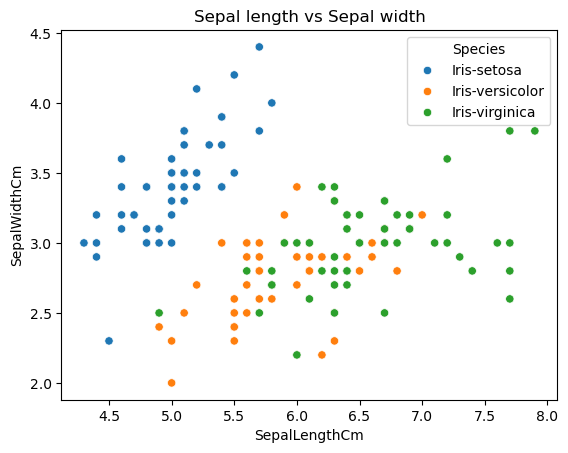

In [9]:
sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species"
)

plt.title("Sepal length vs Sepal width")
plt.show()

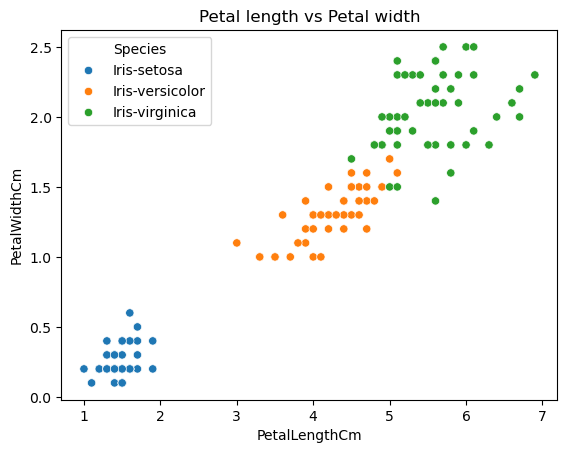

In [10]:
sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species"
)

plt.title("Petal length vs Petal width")
plt.show()



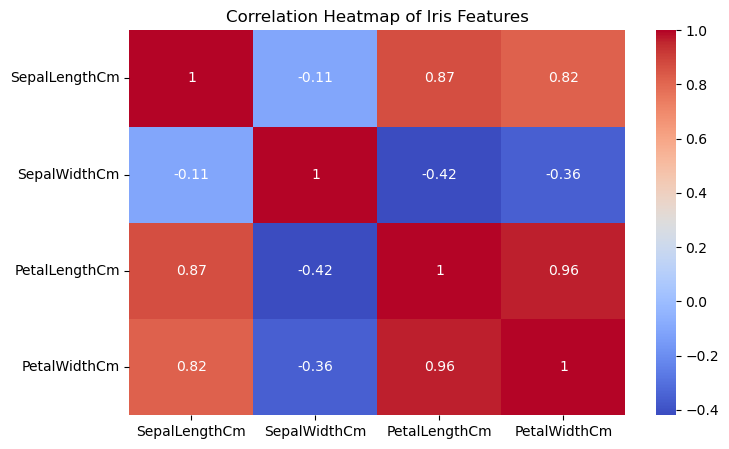

In [11]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.drop(columns=["Id", "Species"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Iris Features")
plt.show()

In [12]:
X = df.drop(columns=["Id", "Species"])
y = df["Species"]

In [13]:
print(X.head())
print(y.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
print("Training data shape:", X_train.shape)
print("Training data shape:", X_test.shape)

Training data shape: (120, 4)
Training data shape: (30, 4)


In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)

In [18]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [19]:
y_pred = knn.predict(X_test)

In [20]:
print(y_pred)

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


In [21]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print ("Accuracy:", accuracy)

Accuracy: 1.0


In [22]:
from sklearn.metrics import confusion_matrix 
cm = confusion_matrix(y_test, y_pred)
print (cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


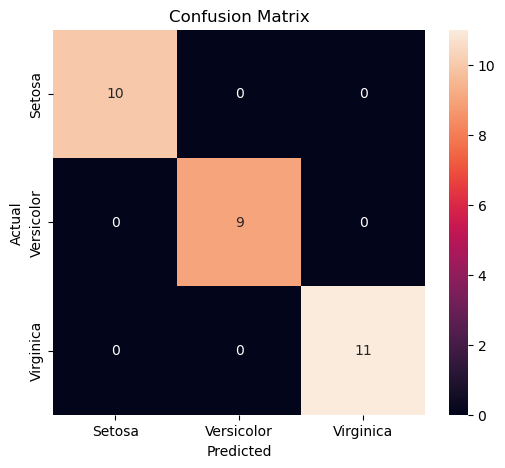

In [23]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Setosa", "Versicolor", "Virginica"],
    yticklabels=["Setosa", "Versicolor", "Virginica"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


    

In [24]:
from sklearn.metrics import  classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [25]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
)

prediction = knn.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


In [59]:
print("===== IRIS FLOWER PREDICTION =====")
print("Enter values within the allowed ranges.\n")

# Allowed ranges based on the Iris dataset
ranges = {
    "Sepal Length": (4.3, 7.9),
    "Sepal Width": (2.0, 4.4),
    "Petal Length": (1.0, 6.9),
    "Petal Width": (0.1, 2.5)
}

# Display ranges
for feature, (minimum, maximum) in ranges.items():
    print(f"{feature}: {minimum} - {maximum} cm")

print()

# Take input
sepal_length = float(input("Enter Sepal Length (cm): "))
sepal_width = float(input("Enter Sepal Width (cm): "))
petal_length = float(input("Enter Petal Length (cm): "))
petal_width = float(input("Enter Petal Width (cm): "))

# Validate input
if not (4.3 <= sepal_length <= 7.9):
    print("Error: Sepal Length must be between 4.3 and 7.9 cm.")

elif not (2.0 <= sepal_width <= 4.4):
    print("Error: Sepal Width must be between 2.0 and 4.4 cm.")

elif not (1.0 <= petal_length <= 6.9):
    print("Error: Petal Length must be between 1.0 and 6.9 cm.")

elif not (0.1 <= petal_width <= 2.5):
    print("Error: Petal Width must be between 0.1 and 2.5 cm.")

else:
    # Create input DataFrame
    new_flower = pd.DataFrame(
        [[sepal_length, sepal_width, petal_length, petal_width]],
        columns=[
            "SepalLengthCm",
            "SepalWidthCm",
            "PetalLengthCm",
            "PetalWidthCm"
        ]
    )

    # Predict
    prediction = knn.predict(new_flower)

    print("\nPredicted Species:", prediction[0])

===== IRIS FLOWER PREDICTION =====
Enter values within the allowed ranges.

Sepal Length: 4.3 - 7.9 cm
Sepal Width: 2.0 - 4.4 cm
Petal Length: 1.0 - 6.9 cm
Petal Width: 0.1 - 2.5 cm



Enter Sepal Length (cm):  5.6
Enter Sepal Width (cm):  2.3
Enter Petal Length (cm):  4.2
Enter Petal Width (cm):  2.2



Predicted Species: Iris-virginica
